# Analisis Data Menggunakan Decision Tree

## Pendahuluan

Pada proyek ini dilakukan analisis data menggunakan metode **Decision Tree** atau pohon keputusan. Decision Tree merupakan salah satu metode klasifikasi dalam data mining yang digunakan untuk memprediksi suatu kelas berdasarkan atribut tertentu pada data.

Metode ini membentuk struktur seperti pohon yang terdiri dari **root node**, **branch**, dan **leaf node**. Root node digunakan sebagai titik awal pengambilan keputusan, branch menunjukkan aturan atau kondisi tertentu, sedangkan leaf node menunjukkan hasil akhir klasifikasi.

Dataset yang digunakan pada penelitian ini adalah dataset **Heart Disease** yang berisi data kesehatan pasien untuk memprediksi kemungkinan penyakit jantung berdasarkan beberapa atribut medis.

Target klasifikasi pada dataset ini terdiri dari:

- **0 = Tidak memiliki penyakit jantung**
- **1 = Memiliki penyakit jantung**

Model klasifikasi dibangun menggunakan node **Decision Tree Learner** pada KNIME dengan metode pengukuran **Gain Ratio** untuk menentukan atribut terbaik dalam proses pembentukan pohon keputusan.

Pada bagian ini dapat ditambahkan screenshot workflow KNIME yang digunakan selama proses analisis data.

## Konsep Dasar Decision Tree

Decision Tree atau pohon keputusan merupakan metode klasifikasi yang bekerja dengan memilih atribut paling informatif untuk membagi data ke dalam beberapa kelompok yang lebih homogen. Tujuan dari proses ini adalah agar setiap kelompok data memiliki karakteristik yang lebih jelas sehingga proses klasifikasi dapat dilakukan dengan lebih akurat.

Struktur Decision Tree terdiri dari:

- **Root node**, yaitu simpul awal yang digunakan sebagai dasar pengambilan keputusan.
- **Branch**, yaitu cabang yang menunjukkan aturan atau kondisi tertentu.
- **Leaf node**, yaitu hasil akhir atau kelas prediksi dari proses klasifikasi.

Proses pembentukan Decision Tree dilakukan melalui beberapa tahapan berikut:

1. Sistem membaca data training dari dataset Heart Disease.
2. Sistem menghitung kualitas setiap atribut menggunakan metode **Gain Ratio**.
3. Atribut dengan nilai terbaik dipilih sebagai **root node**.
4. Data dibagi menjadi beberapa cabang berdasarkan atribut yang dipilih.
5. Proses pembagian dilakukan secara berulang hingga data pada setiap cabang menjadi cukup homogen.

## Pengukuran Menggunakan Gain Ratio

Pada penelitian ini, proses pembentukan pohon keputusan menggunakan metode **Gain Ratio**. Gain Ratio digunakan untuk menentukan atribut terbaik yang akan dijadikan node pada Decision Tree.

Gain Ratio merupakan pengembangan dari Information Gain yang bertujuan untuk mengurangi bias terhadap atribut yang memiliki banyak nilai unik. Metode ini menghitung kualitas atribut berdasarkan kemampuan atribut tersebut dalam membagi data dengan lebih baik.

Rumus Gain Ratio adalah:

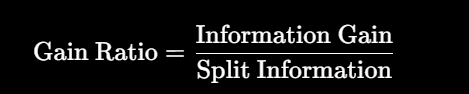

Information Gain dihitung dengan rumus:

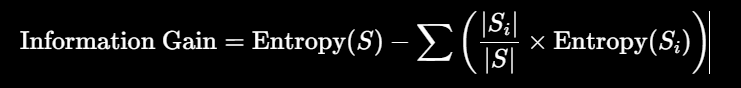

Split Information dihitung dengan rumus:

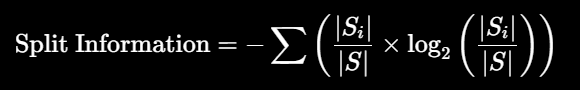

Keterangan:

- \(S\) = seluruh data
- \(S_i\) = subset data setelah dibagi berdasarkan atribut tertentu
- \(|S|\) = jumlah seluruh data
- \(|S_i|\) = jumlah data pada subset ke-i
- \(Entropy(S)\) = tingkat ketidakpastian data
- \(Split\ Information\) = ukuran pembagian data berdasarkan atribut

Atribut dengan nilai Gain Ratio tertinggi akan dipilih sebagai node terbaik dalam proses pembentukan pohon keputusan. Dengan menggunakan Gain Ratio, hasil klasifikasi yang diperoleh dapat menjadi lebih optimal dan akurat.

## Preprocessing Data
Sebelum data masuk dalam proses pemodelan, dilakukan beberapa tahap preprocessing.

### 1. Missing Value
Missing value adalah data yang hilang atau kosong dalam suatu dataset. Biasanya ditandai dengan nilai seperti NULL, NaN, atau sel kosong.

Pada proses ini data heart disease tidak memiliki missing value jadi tidak dilakukan proses imputasi pada data. Hal ini bisa dilihat pada gambar berikut

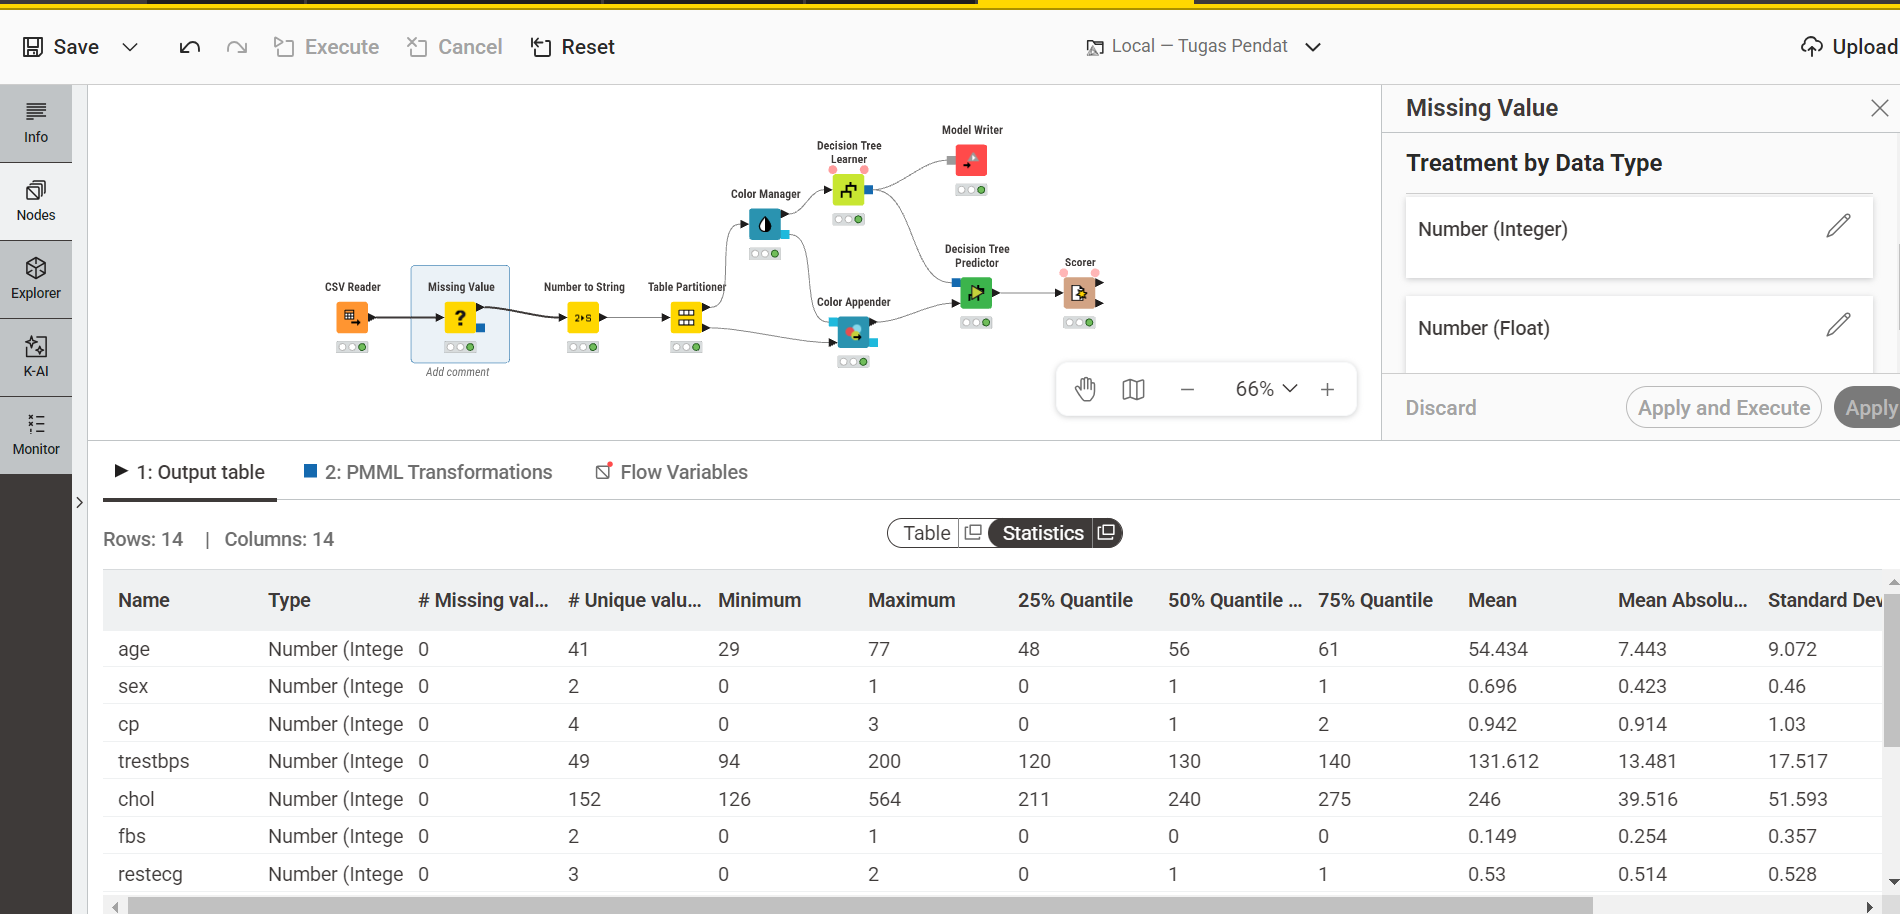

Pada gambar tersebut pada kolom missing values disetiap fiturnya tidak ada data yang memiliki missing value ditandai dengan angka nol tersebut.

### Tanpa Normalisasi Data

Pada penelitian ini, metode Decision Tree tidak menggunakan proses normalisasi data. Hal ini dikarenakan Decision Tree bekerja dengan cara membagi data berdasarkan aturan atau kondisi tertentu pada atribut, bukan berdasarkan perhitungan jarak antar data.

Metode Decision Tree tetap dapat bekerja dengan baik meskipun data memiliki rentang nilai yang berbeda-beda. Oleh karena itu, proses normalisasi tidak wajib dilakukan pada algoritma ini.

Selain itu, penggunaan normalisasi pada Decision Tree umumnya tidak memberikan pengaruh yang signifikan terhadap hasil klasifikasi, sehingga data dapat langsung digunakan setelah proses penanganan missing value selesai dilakukan.

## Workflow KNIME
Alur proses yang digunakan adalah:

CSV Reader => Missing Value => Number to String => Table Partitioner => Color Manager => Color Appender => Decision Tree Learner => Model Writer => Decision Tree Predictor => Scorer

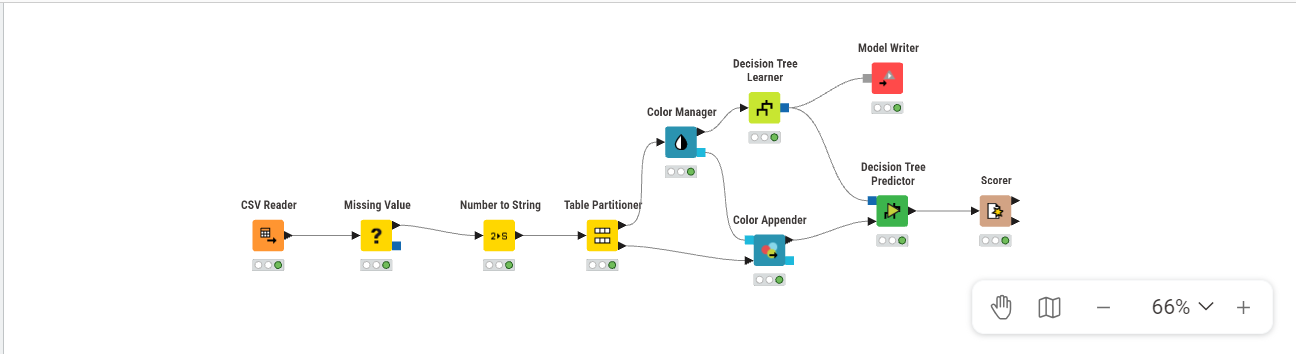

## Penjelasan Node

### a. CSV Reader
Berguna untuk membaca dataset dari file CSV. Di tahap ini data dimasukkan ke dalam KNIME.

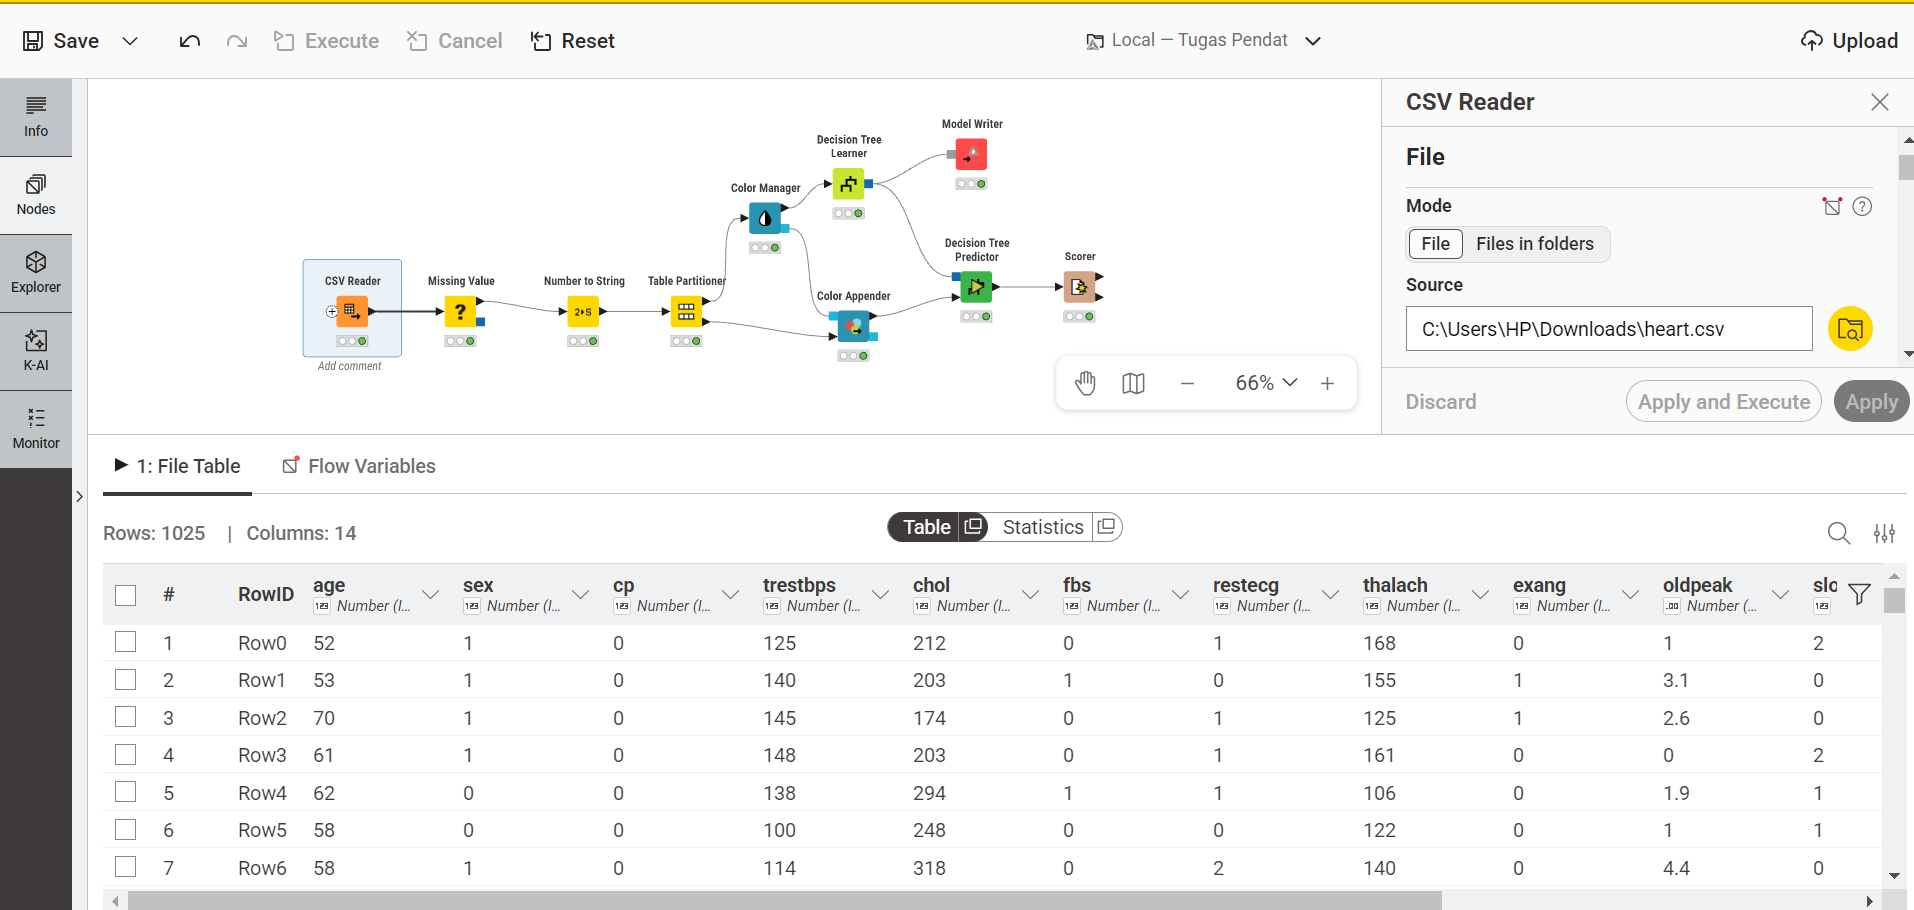

### b. Missing Value
Pada tahap ini digunakan node Missing Value untuk memastikan tidak terdapat data kosong sebelum masuk ke proses selanjutnya. Langkah ini penting karena nilai yang hilang dapat mempengaruhi hasil normalisasi dan performa model.

Berdasarkan workflow yang digunakan, node Missing Value diletakkan setelah CSV Reader dan sebelum Normalizer. Hal ini bertujuan agar data yang dinormalisasi sudah dalam kondisi bersih.

Konfigurasi yang diterapkan pada node ini mengikuti pengaturan Treatment by Data Type, yaitu:

Untuk data bertipe Number (Integer) dan Number (Float), nilai kosong digantikan menggunakan nilai rata-rata (mean)
Jika terdapat data bertipe string, maka akan diisi dengan nilai yang paling sering muncul (most frequent value)
Kolom target tidak dilakukan perubahan karena digunakan sebagai label dalam proses klasifikasi
Dari hasil yang terlihat pada bagian statistik, dataset tidak memiliki nilai kosong (missing value = 0 pada setiap kolom). Namun, penggunaan node ini tetap dilakukan sebagai langkah antisipasi untuk memastikan kualitas data tetap terjaga.

Dengan proses ini, data menjadi lebih siap untuk tahap normalisasi dan pemodelan tanpa adanya gangguan dari nilai yang hilang.

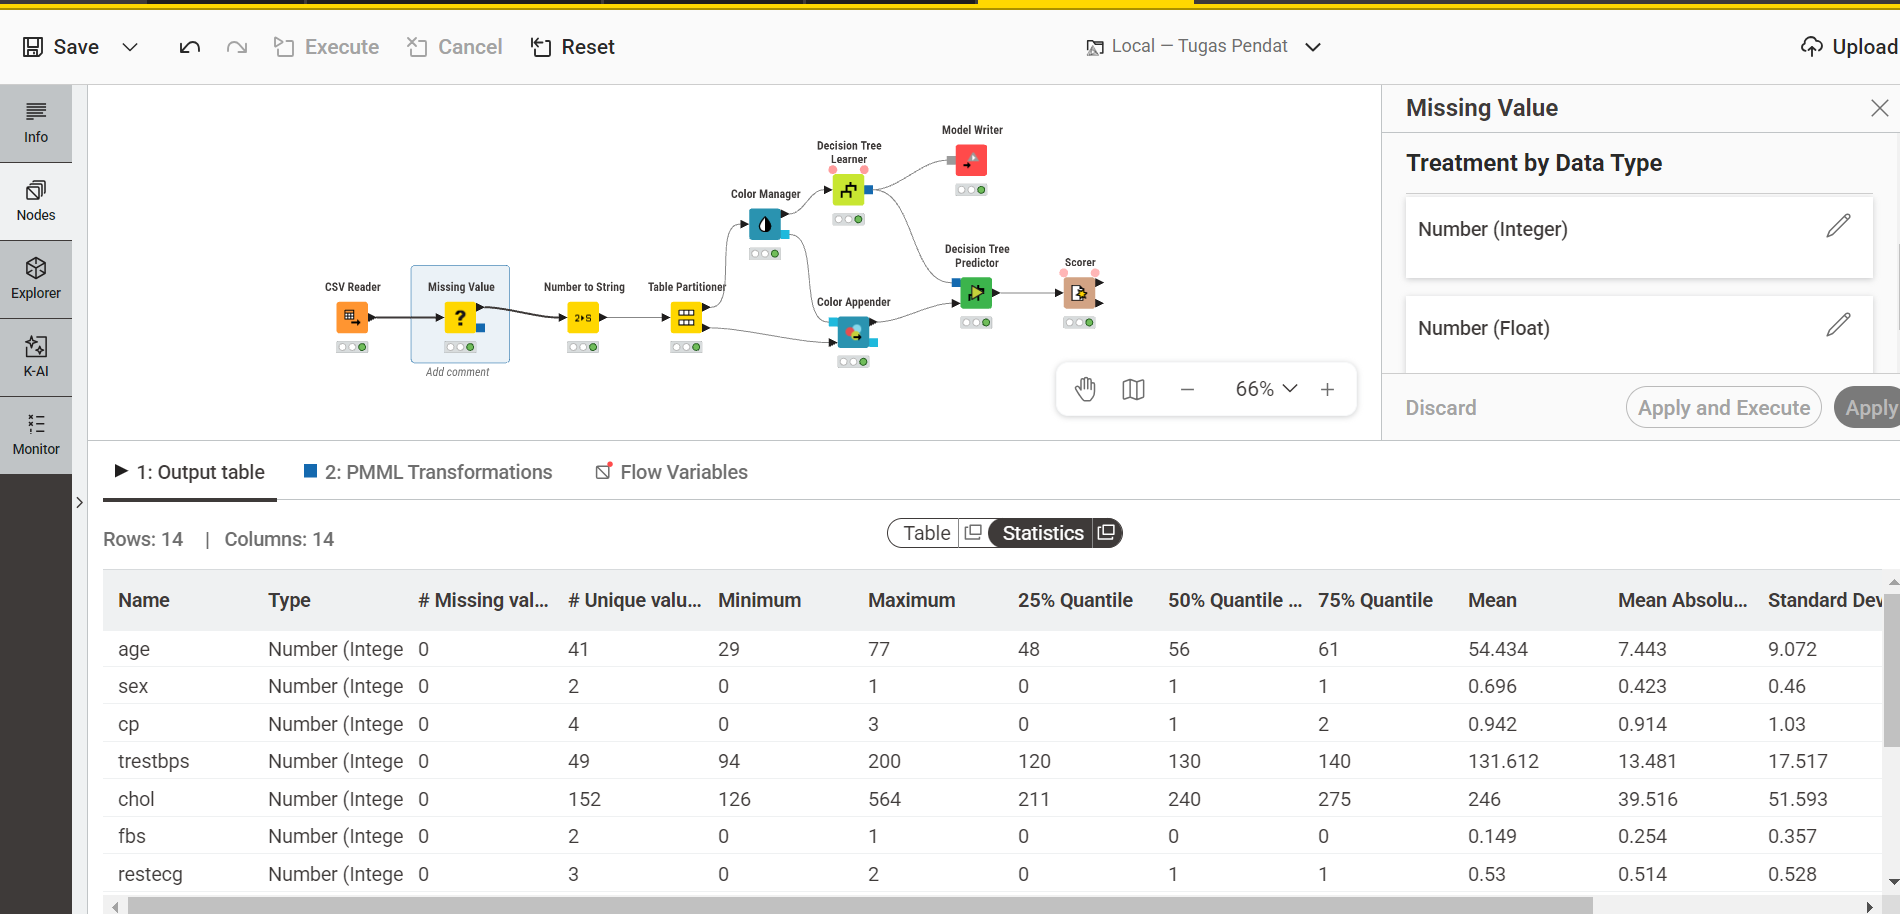

### c. Number to String

Pada tahap ini digunakan node **Number to String** untuk mengubah tipe data pada kolom target dari numerik menjadi string atau kategori. Proses ini dilakukan karena algoritma Decision Tree pada KNIME membutuhkan atribut target dalam bentuk kategori agar dapat melakukan proses klasifikasi dengan benar.

Pada dataset Heart Disease, kolom target memiliki nilai:
- 0 = Tidak memiliki penyakit jantung
- 1 = Memiliki penyakit jantung

Nilai tersebut awalnya terbaca sebagai angka (numeric), sehingga perlu dikonversi menjadi tipe string menggunakan node Number to String.

Pada proses ini hanya kolom **target** yang dikonversi, sedangkan atribut lainnya tetap menggunakan tipe numerik agar dapat digunakan dalam proses pembentukan pohon keputusan secara optimal.

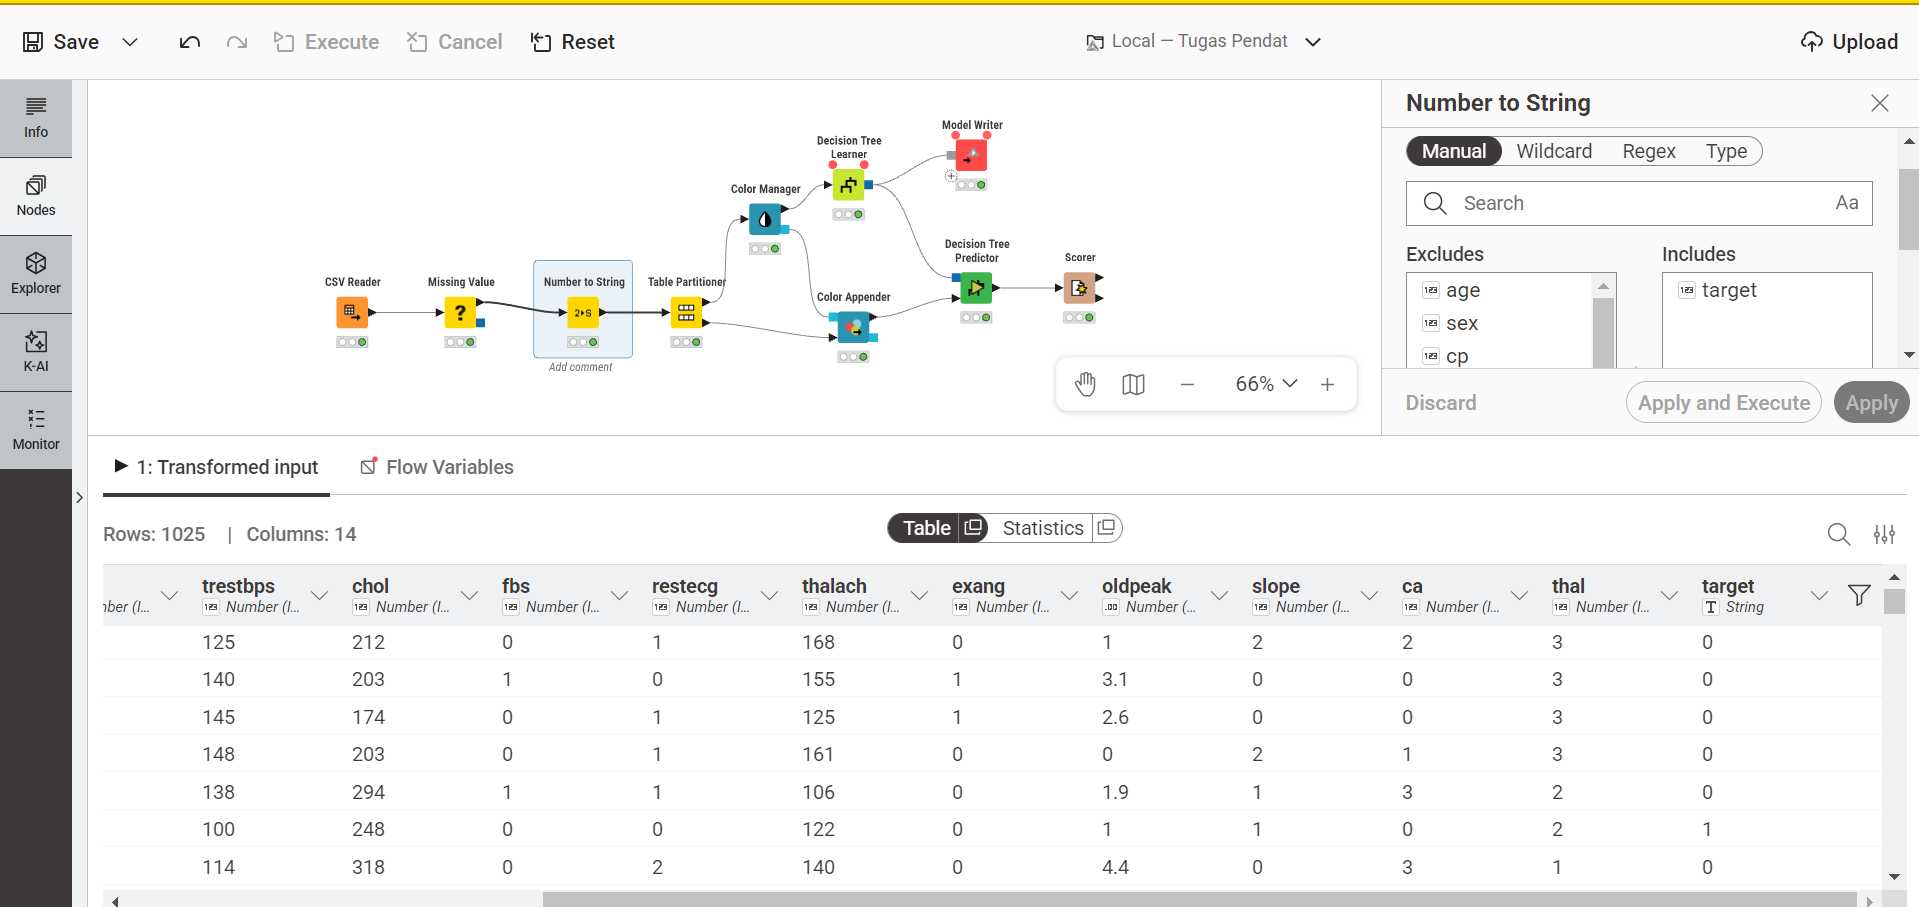

### d. Table Partitioner

Pada tahap ini digunakan node **Table Partitioner** untuk membagi dataset menjadi data training dan data testing. Proses pembagian data dilakukan agar model Decision Tree dapat dilatih menggunakan sebagian data, kemudian diuji menggunakan data lainnya untuk mengetahui performa klasifikasi.

Pada penelitian ini, data dibagi dengan perbandingan:
- **70% data training**
- **30% data testing**

Metode pembagian yang digunakan adalah **Random Sampling**, sehingga data dipilih secara acak agar distribusi data lebih merata dan model tidak hanya mempelajari pola tertentu saja.

Data training digunakan pada node **Decision Tree Learner** untuk membangun model klasifikasi, sedangkan data testing digunakan pada node **Decision Tree Predictor** untuk menguji hasil prediksi model yang telah dibuat.

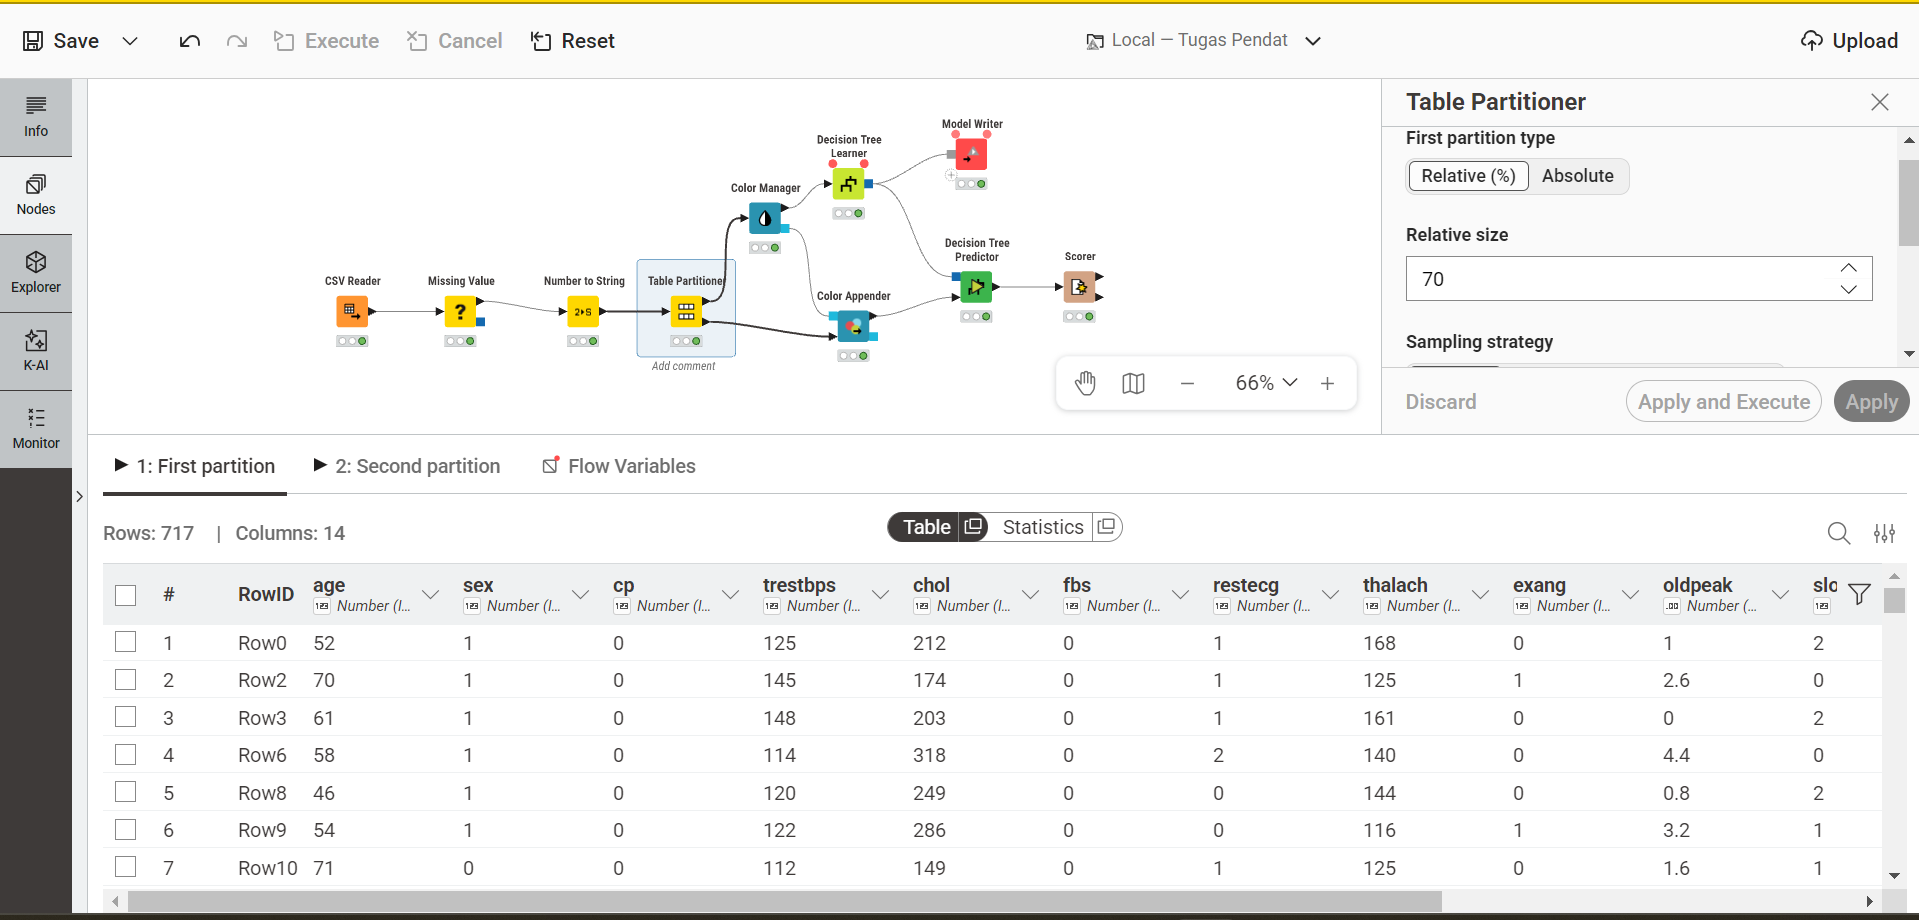

### e. Pewarnaan Data Menggunakan Color Manager

Pada tahap ini digunakan node **Color Manager** untuk memberikan warna pada data berdasarkan nilai target pada dataset Heart Disease. Pewarnaan dilakukan agar proses visualisasi data dan hasil klasifikasi menjadi lebih mudah dipahami.

Pada penelitian ini:
- data dengan nilai target **0** diberikan warna hijau yang menunjukkan pasien tidak memiliki penyakit jantung,
- sedangkan data dengan nilai target **1** diberikan warna merah yang menunjukkan pasien memiliki penyakit jantung.

Node **Color Manager** menghasilkan informasi warna berdasarkan kelas data, kemudian informasi tersebut diterapkan pada data menggunakan node **Color Appender**.

Penggunaan warna membantu dalam membedakan setiap kelas data secara visual sehingga hasil analisis dan proses interpretasi model Decision Tree menjadi lebih jelas. Namun, proses pewarnaan ini tidak mempengaruhi performa model klasifikasi karena hanya digunakan untuk kebutuhan visualisasi.

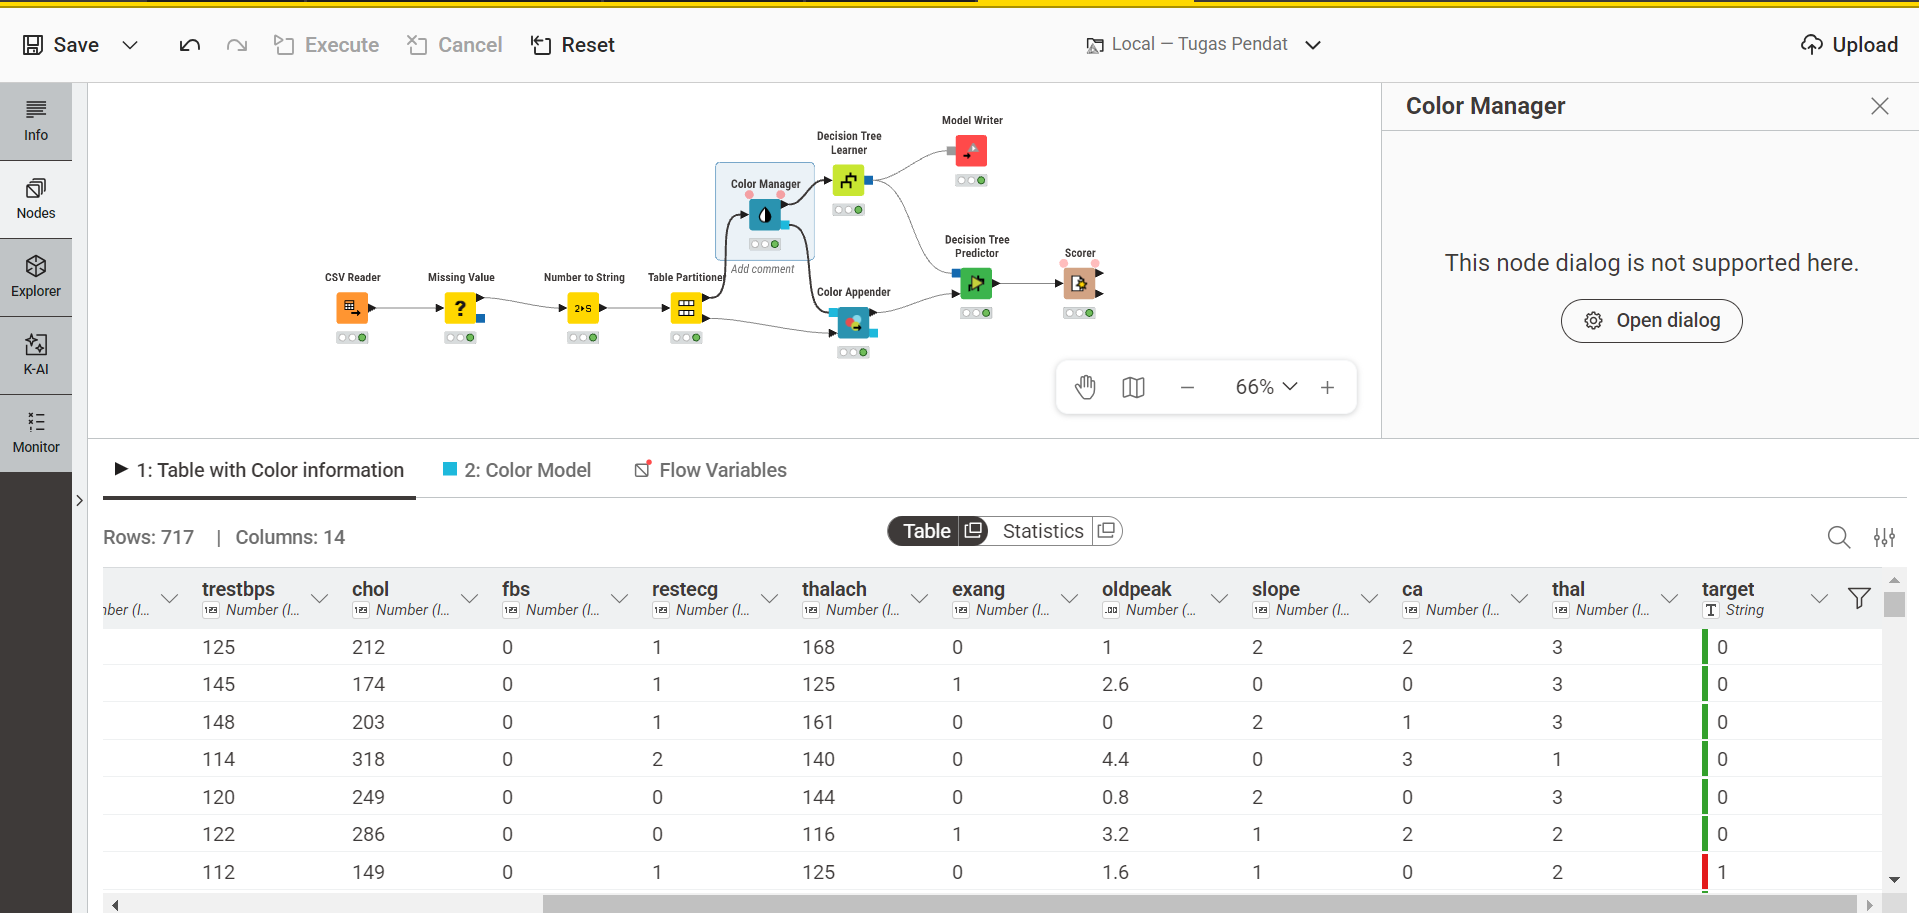

### f. Penerapan Warna Menggunakan Color Appender

Pada tahap ini digunakan node **Color Appender** untuk menerapkan informasi warna yang telah dibuat sebelumnya pada node Color Manager ke dalam data testing.

Node Color Appender berfungsi untuk menambahkan pengaturan warna pada setiap data berdasarkan nilai target sehingga hasil visualisasi data menjadi lebih jelas dan mudah dipahami.

Pada penelitian ini:
- warna hijau menunjukkan data dengan target **0** atau tidak memiliki penyakit jantung,
- sedangkan warna merah menunjukkan data dengan target **1** atau memiliki penyakit jantung.

Hasil dari proses ini menampilkan data testing beserta pewarnaan kelas pada kolom target. Pewarnaan tersebut membantu dalam membedakan setiap kelas data secara visual saat proses prediksi dan evaluasi model dilakukan.

Penggunaan Color Appender tidak mempengaruhi proses klasifikasi maupun hasil accuracy model, melainkan hanya digunakan untuk kebutuhan visualisasi data pada workflow KNIME.

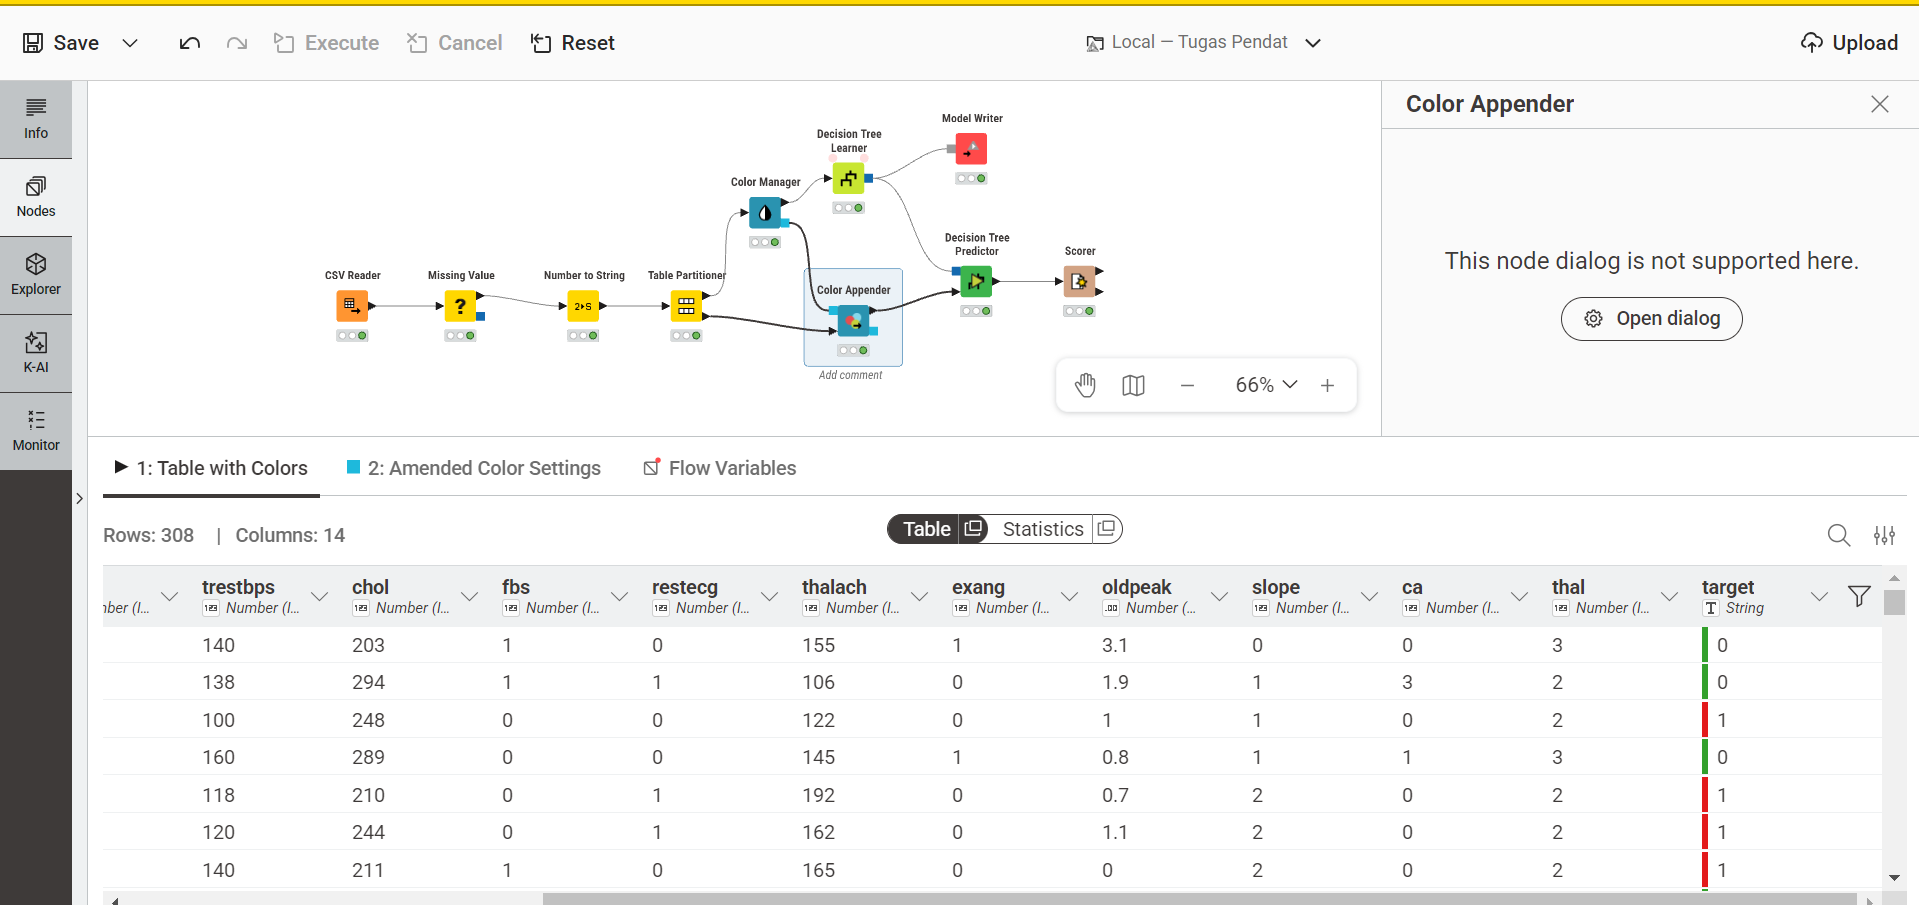

### g. Decision Tree Learner
Pada tahap ini digunakan node Decision Tree Learner untuk membangun model klasifikasi berdasarkan data training yang telah diproses sebelumnya. Node ini bekerja dengan membentuk struktur pohon keputusan untuk memprediksi target pada dataset Heart Disease.

Kolom target digunakan sebagai class column atau label klasifikasi yang akan diprediksi oleh sistem. Model kemudian akan mencari atribut terbaik yang dapat digunakan untuk membagi data menjadi beberapa kelompok yang lebih homogen.

Pada penelitian ini digunakan metode pengukuran Gain Ratio sebagai quality measure. Gain Ratio digunakan untuk menentukan atribut terbaik pada setiap proses pembentukan node dalam Decision Tree.

Selain itu, digunakan metode No Pruning sehingga seluruh cabang pohon keputusan tetap dipertahankan selama proses pembentukan model. Pengaturan ini memungkinkan model membentuk struktur pohon secara lebih lengkap berdasarkan pola data training.

Hasil dari proses ini berupa model Decision Tree yang selanjutnya digunakan pada tahap prediksi menggunakan node Decision Tree Predictor.

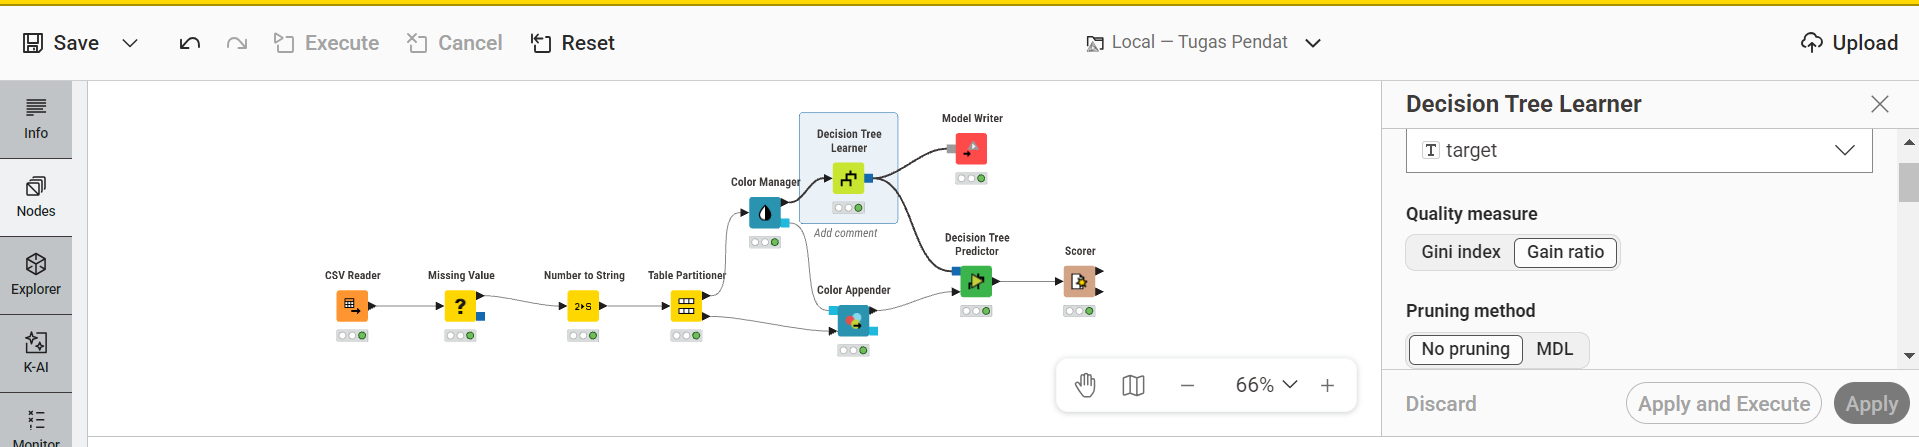

### h. Model Writer

Pada tahap ini digunakan node **Model Writer** untuk menyimpan model Decision Tree yang telah berhasil dibangun sebelumnya. Proses penyimpanan model dilakukan agar model dapat digunakan kembali tanpa perlu melakukan proses training ulang.

Model disimpan dalam bentuk file dengan format **.model** pada lokasi penyimpanan yang telah ditentukan pada sistem komputer.

Penggunaan Model Writer mempermudah proses dokumentasi dan penggunaan ulang model klasifikasi pada penelitian selanjutnya. Selain itu, model yang telah disimpan dapat digunakan kembali untuk proses prediksi tanpa harus membangun model dari awal.

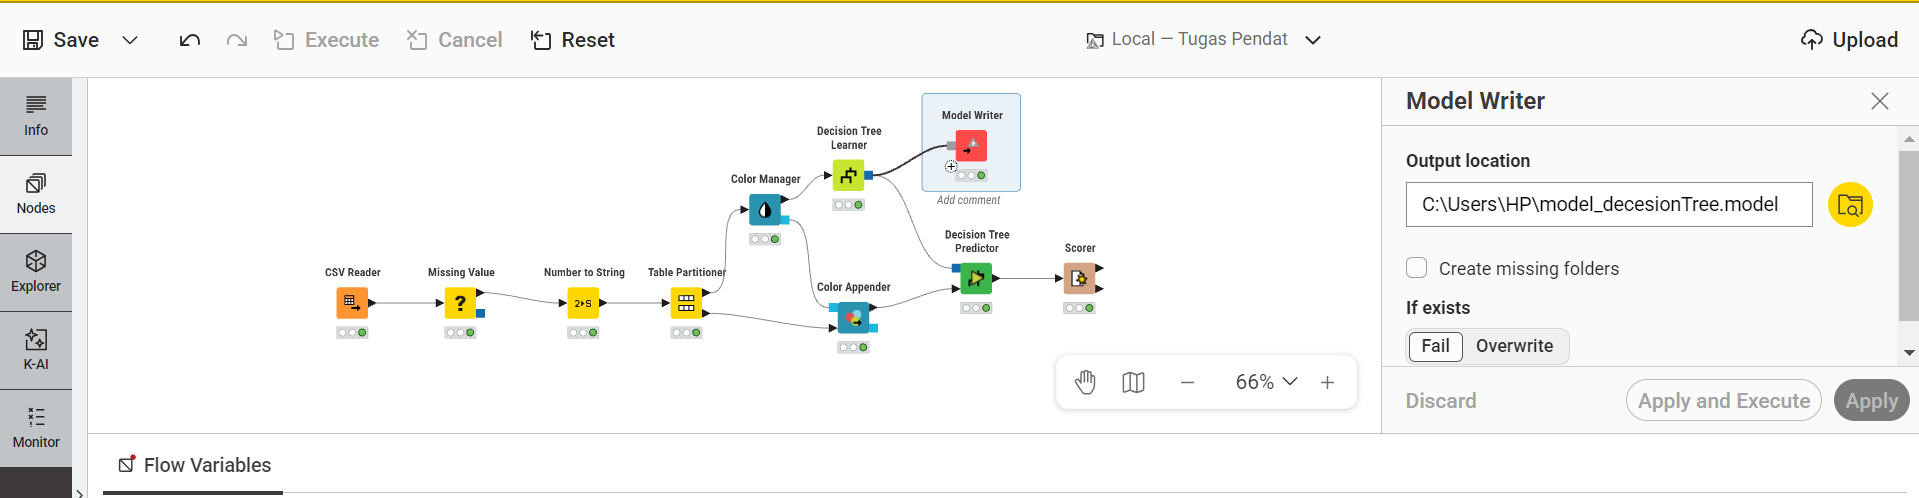

### i. Decision Tree Predictor
Pada tahap ini digunakan node Decision Tree Predictor untuk melakukan proses prediksi terhadap data testing menggunakan model Decision Tree yang telah dibangun sebelumnya.

Node ini menerima dua input, yaitu:

model Decision Tree dari node Decision Tree Learner
data testing dari node Table Partitioner
Proses prediksi dilakukan dengan membaca pola dan aturan yang telah terbentuk pada model Decision Tree, kemudian menentukan hasil klasifikasi untuk setiap data testing.

Hasil prediksi ditampilkan pada kolom Prediction(target). Kolom tersebut berisi hasil klasifikasi yang diprediksi oleh model berdasarkan atribut pada dataset Heart Disease.

Nilai prediksi yang dihasilkan terdiri dari:

0 = Tidak memiliki penyakit jantung
1 = Memiliki penyakit jantung
Hasil dari node Decision Tree Predictor selanjutnya digunakan pada tahap evaluasi model menggunakan node Scorer untuk mengetahui tingkat akurasi klasifikasi yang dihasilkan.

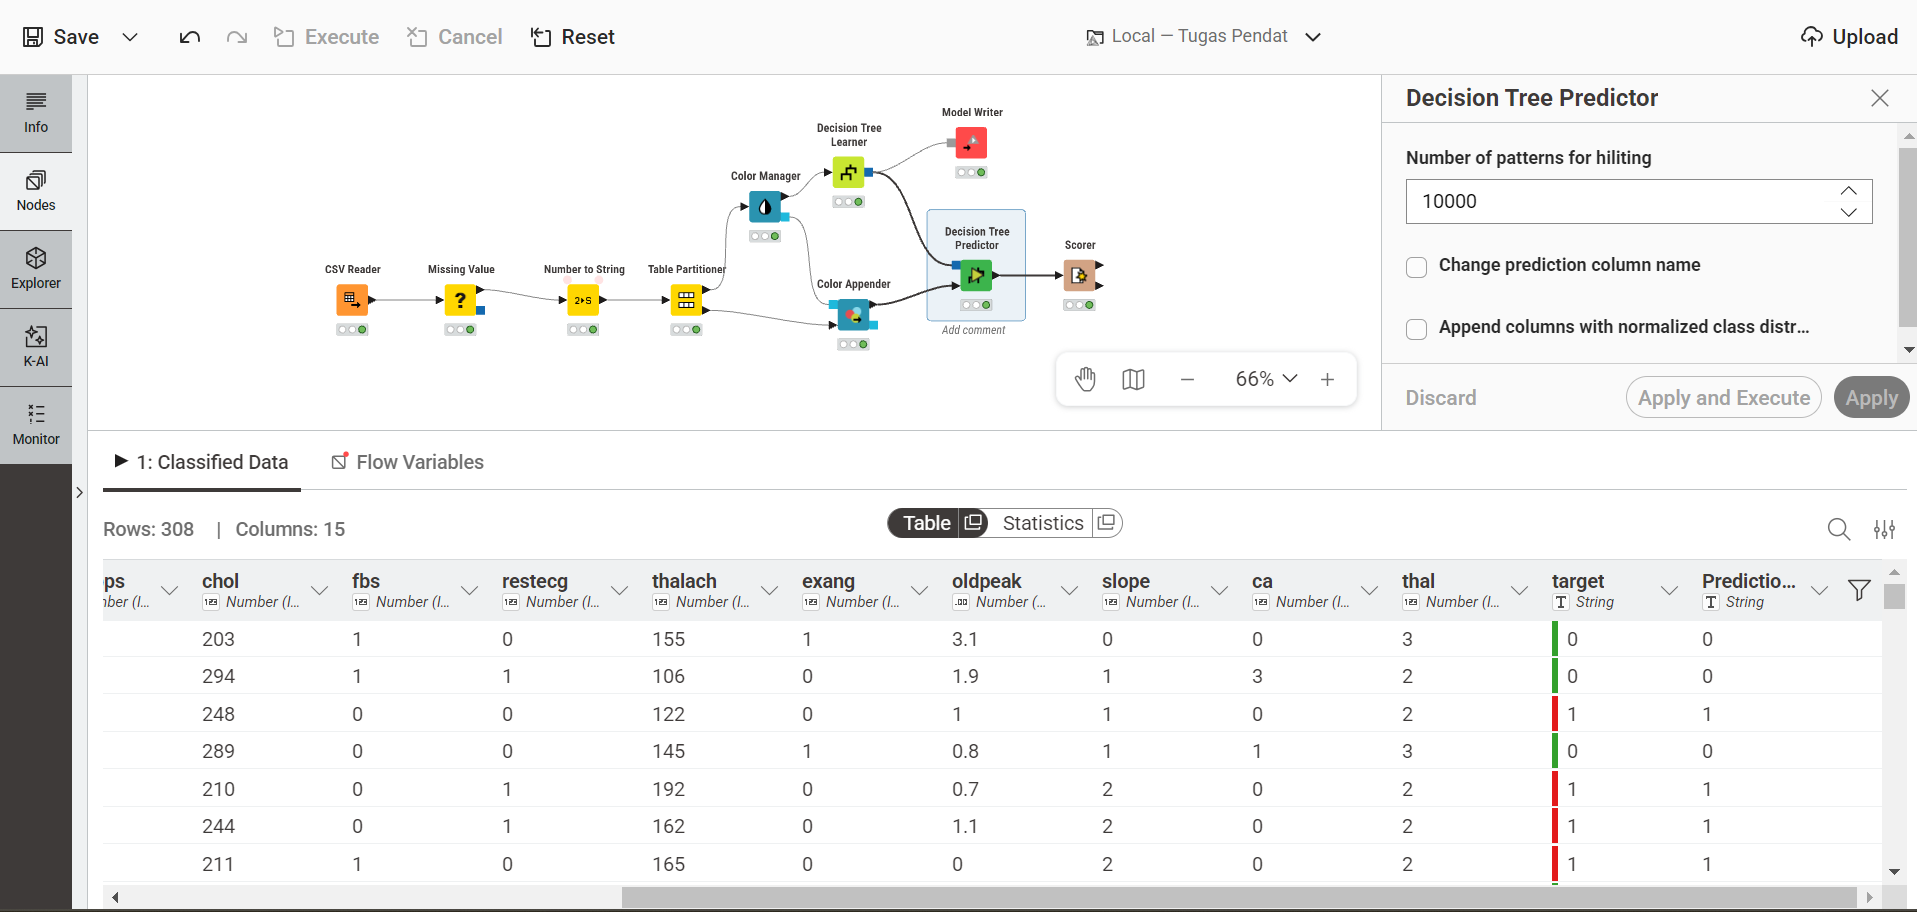

### j. Scorer
Pada tahap ini digunakan node **Scorer** untuk melakukan evaluasi terhadap hasil prediksi yang dihasilkan oleh model Decision Tree. Evaluasi dilakukan dengan membandingkan data asli pada kolom **target** dengan hasil prediksi pada kolom **Prediction(target)**.

Hasil evaluasi ditampilkan dalam bentuk **Confusion Matrix** dan nilai akurasi klasifikasi.

Berdasarkan hasil pengujian diperoleh:

- **Correct classified : 291 data**
- **Wrong classified : 17 data**
- **Accuracy : 94.481%**
- **Error : 5.519%**
- **Cohen’s Kappa : 0.89**

Nilai akurasi sebesar **94.481%** menunjukkan bahwa model Decision Tree mampu melakukan klasifikasi data Heart Disease dengan sangat baik. Dari total data testing, sebagian besar data berhasil diprediksi dengan benar oleh model.

Pada Confusion Matrix diperoleh hasil:

| Prediksi | Aktual 1 | Aktual 0 |
|---|---|---|
| Prediksi 1 | 142 | 6 |
| Prediksi 0 | 11 | 149 |

Keterangan:
- 142 data berhasil diprediksi benar sebagai kelas 1.
- 149 data berhasil diprediksi benar sebagai kelas 0.
- 6 data diprediksi kelas 1 tetapi sebenarnya kelas 0.
- 11 data diprediksi kelas 0 tetapi sebenarnya kelas 1.

Hasil tersebut menunjukkan bahwa model Decision Tree dengan metode Gain Ratio mampu menghasilkan performa klasifikasi yang cukup baik pada dataset Heart Disease.

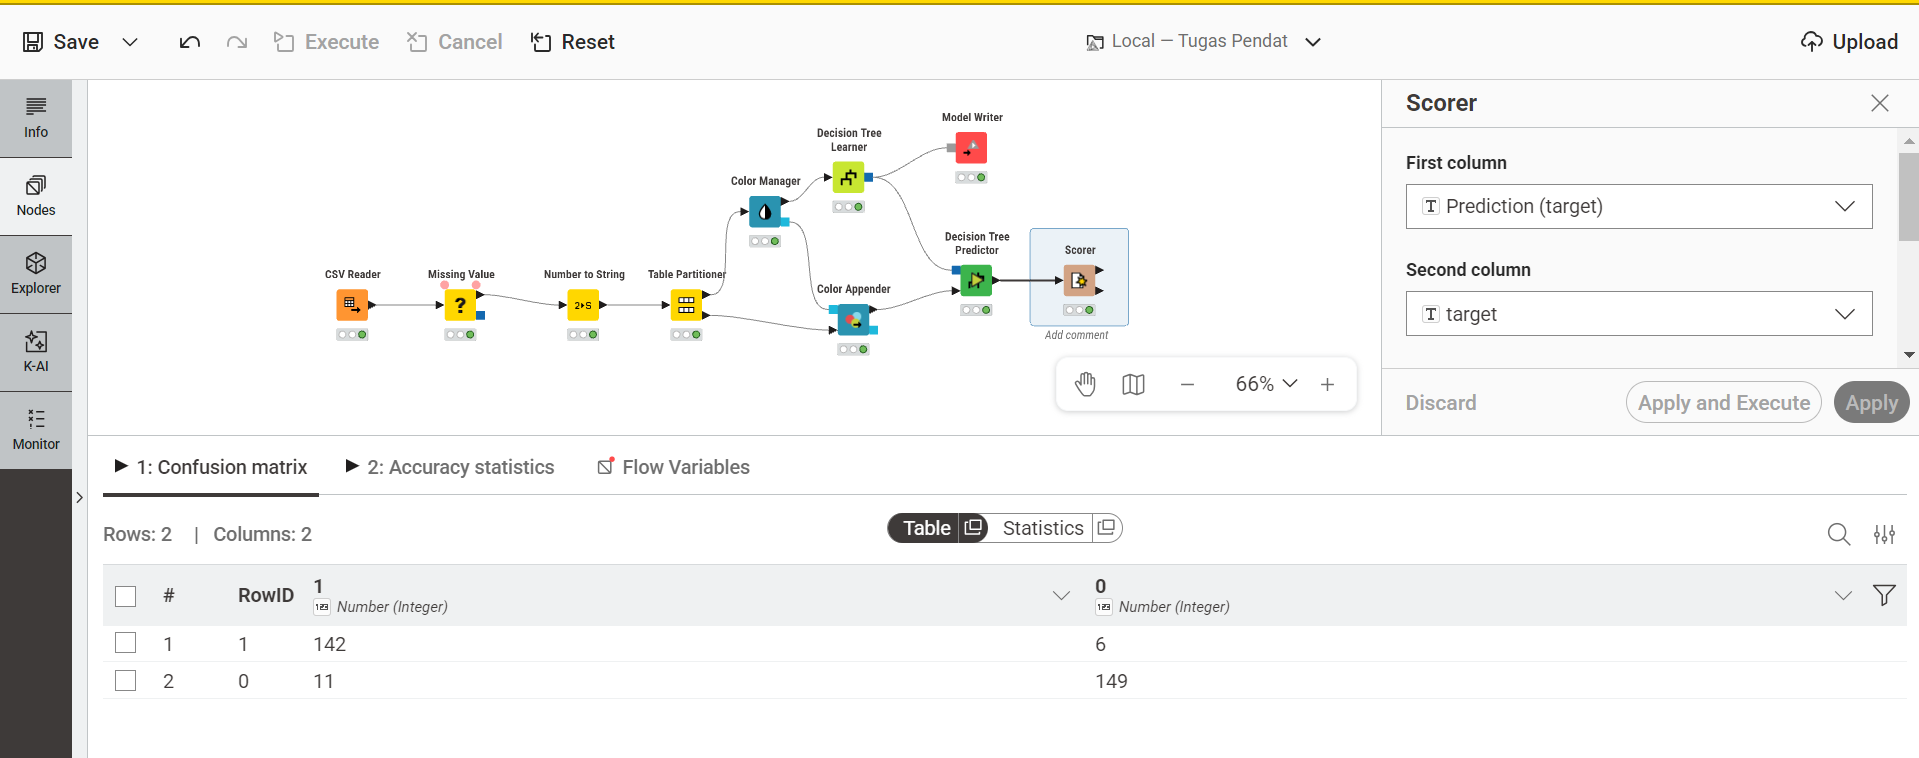

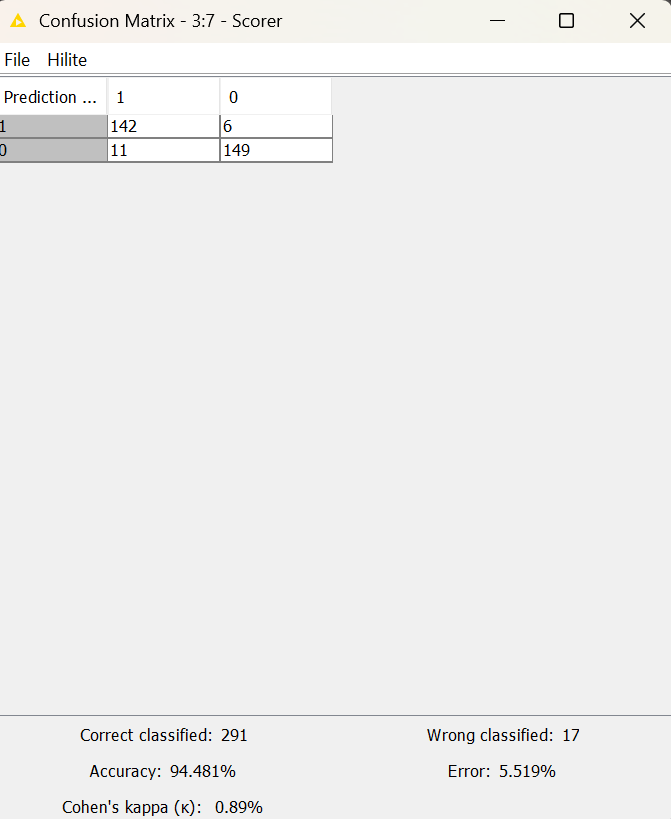

## Perhitungan Evaluasi

Berdasarkan hasil pengujian model menggunakan node **Scorer**, diperoleh hasil sebagai berikut:

* Jumlah data yang diprediksi dengan benar: **291**
* Jumlah data yang diprediksi salah: **17**
* Total data: **308**

Perhitungan akurasi dilakukan dengan rumus:

$$
Accuracy = \frac{Jumlah\ Prediksi\ Benar}{Total\ Data} \times 100\%
$$

Sehingga diperoleh:

$$
Accuracy = \frac{291}{308} \times 100\% = 94.48\%
$$

Nilai error dihitung sebagai:

$$
Error = 100\% - Accuracy
$$

$$
Error = 100\% - 94.48\% = 5.52\%
$$

Selain itu, nilai **Cohen’s Kappa sebesar 0.89** menunjukkan bahwa tingkat kesesuaian antara hasil prediksi dan data sebenarnya berada pada kategori sangat baik.

## Analisis Hasil

Berdasarkan hasil evaluasi model menggunakan metode Decision Tree dengan pengukuran Gain Ratio, diperoleh nilai accuracy sebesar **94.48%**. Nilai tersebut menunjukkan bahwa model mampu melakukan klasifikasi data Heart Disease dengan tingkat ketepatan yang sangat baik.

Model berhasil mengklasifikasikan sebanyak **291 data** dengan benar dan hanya terdapat **17 data** yang mengalami kesalahan prediksi. Hal ini menunjukkan bahwa penggunaan Gain Ratio pada Decision Tree mampu memilih atribut terbaik dalam proses pembentukan pohon keputusan.

Nilai precision sebesar **95.95%** menunjukkan bahwa sebagian besar data yang diprediksi memiliki penyakit jantung memang benar termasuk kelas tersebut. Sedangkan nilai recall sebesar **92.81%** menunjukkan bahwa model mampu mendeteksi sebagian besar pasien yang memiliki penyakit jantung.

Hasil confusion matrix juga menunjukkan bahwa jumlah prediksi benar lebih dominan dibandingkan kesalahan klasifikasi, sehingga model dapat dikatakan memiliki performa yang baik dalam melakukan prediksi pada dataset Heart Disease.

## Kesimpulan

Berdasarkan penelitian yang telah dilakukan, metode Decision Tree dengan pengukuran Gain Ratio berhasil diterapkan pada dataset Heart Disease untuk melakukan klasifikasi penyakit jantung.

Proses analisis dilakukan melalui beberapa tahapan, yaitu preprocessing data, penanganan missing value, konversi target menggunakan Number to String, pembagian data training dan testing, pembentukan model menggunakan Decision Tree Learner, proses prediksi, serta evaluasi model menggunakan Scorer.

Hasil evaluasi menunjukkan bahwa model memperoleh accuracy sebesar **94.48%**, sehingga dapat disimpulkan bahwa metode Decision Tree mampu menghasilkan performa klasifikasi yang baik pada dataset Heart Disease.

Penggunaan Gain Ratio juga membantu dalam menentukan atribut terbaik pada proses pembentukan pohon keputusan sehingga model dapat menghasilkan prediksi yang lebih optimal dan akurat.